In [1]:
# Problema: Decidir cuántos vehículos reservar antes de conocer los pedidos de mañana, equilibrando el costo fijo de la flota reservada frente al costo de tercerizar los pedidos que no alcance a cubrir.

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import display
from IPython import get_ipython

data_dir = Path("../data")
submission_dir = Path("../submission")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
display(["simulation_parameters.csv"])

['simulation_parameters.csv']

In [2]:
# Cargamos los parametros congelados del caso: nada se calibra dentro del cuaderno.

params = pd.read_csv(data_dir / "simulation_parameters.csv").iloc[0]
display(params)

seed                             42.0
n_scenarios                   20000.0
candidate_fleet_min               4.0
candidate_fleet_max              16.0
fixed_cost_per_vehicle          180.0
outsourcing_cost_per_order       25.0
mean_demand                     120.0
demand_shape_k                    8.0
mean_capacity_per_vehicle        14.0
sd_capacity_per_vehicle           3.0
capacity_floor                    4.0
Name: 0, dtype: float64

In [3]:
# Verificamos que los parametros esten bien definidos antes de simular nada.

SEED = int(params.seed)
N_SCENARIOS = int(params.n_scenarios)
FLEET_MIN = int(params.candidate_fleet_min)
FLEET_MAX = int(params.candidate_fleet_max)
FIXED_COST_PER_VEHICLE = float(params.fixed_cost_per_vehicle)
OUTSOURCING_COST_PER_ORDER = float(params.outsourcing_cost_per_order)
MEAN_DEMAND = float(params.mean_demand)
DEMAND_SHAPE_K = float(params.demand_shape_k)
MEAN_CAPACITY = float(params.mean_capacity_per_vehicle)
SD_CAPACITY = float(params.sd_capacity_per_vehicle)
CAPACITY_FLOOR = float(params.capacity_floor)

assert N_SCENARIOS > 0 and FLEET_MIN < FLEET_MAX
assert FIXED_COST_PER_VEHICLE > 0 and OUTSOURCING_COST_PER_ORDER > 0
assert MEAN_DEMAND > 0 and DEMAND_SHAPE_K > 0
assert MEAN_CAPACITY > 0 and SD_CAPACITY > 0 and CAPACITY_FLOOR > 0
print(f"Flota candidata: {FLEET_MIN}..{FLEET_MAX} vehiculos; {N_SCENARIOS} futuros simulados; semilla {SEED}.")

Flota candidata: 4..16 vehiculos; 20000 futuros simulados; semilla 42.


In [4]:
# La decision es un unico entero: cuantos vehiculos reservar hoy, antes de conocer la demanda de manana.
# Reservar pocos vehiculos implica pagar tercerizacion cuando la demanda excede la capacidad interna.
# Reservar muchos vehiculos implica pagar capacidad fija que puede quedar sin usar; no hay un costo adicional
# de capacidad ociosa: el costo fijo por vehiculo ya lo representa.

print("reserved_fleet_cost = fleet_size * fixed_cost_per_vehicle")
print("outsourced_orders = max(orders - internal_capacity, 0)")
print("total_cost = reserved_fleet_cost + outsourced_orders * outsourcing_cost_per_order")

reserved_fleet_cost = fleet_size * fixed_cost_per_vehicle
outsourced_orders = max(orders - internal_capacity, 0)
total_cost = reserved_fleet_cost + outsourced_orders * outsourcing_cost_per_order


In [5]:
# La demanda diaria es incierta y tiene una cola derecha real: dias inusualmente ocupados ocurren.
# Usamos una mezcla Gamma-Poisson: un multiplicador latente de dia ocupado, y pedidos Poisson dado ese multiplicador.

demand_scale = MEAN_DEMAND / DEMAND_SHAPE_K
demand_variance = MEAN_DEMAND + DEMAND_SHAPE_K * demand_scale ** 2
demand_sd = math.sqrt(demand_variance)
print(f"mu_s ~ Gamma(shape={DEMAND_SHAPE_K}, scale={demand_scale}); D_s ~ Poisson(mu_s)")
print(f"E[D] = {MEAN_DEMAND}")
print(f"Var(D) = E[mu] + Var(mu) = {MEAN_DEMAND} + {DEMAND_SHAPE_K} * {demand_scale}^2 = {demand_variance}")
print(f"SD(D) = sqrt({demand_variance}) = {demand_sd:.3f}")

mu_s ~ Gamma(shape=8.0, scale=15.0); D_s ~ Poisson(mu_s)
E[D] = 120.0
Var(D) = E[mu] + Var(mu) = 120.0 + 8.0 * 15.0^2 = 1920.0
SD(D) = sqrt(1920.0) = 43.818


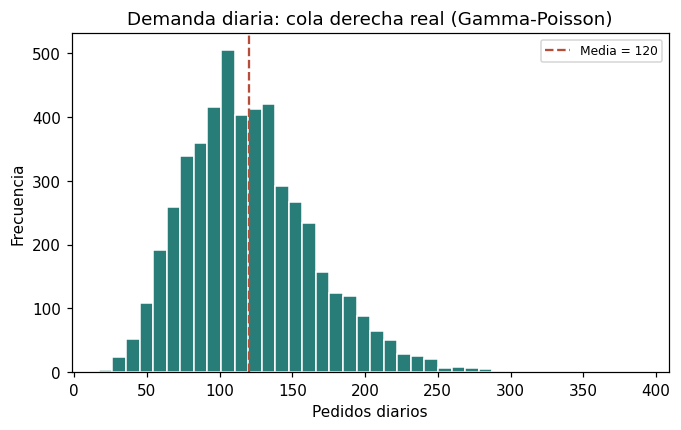

In [6]:
# Visualizamos la forma de la distribucion de demanda antes de generar el conjunto completo de futuros.

preview_rng = np.random.default_rng(SEED)
preview_mu = preview_rng.gamma(DEMAND_SHAPE_K, demand_scale, size=5000)
preview_demand = preview_rng.poisson(preview_mu)

fig_demand, ax_demand = plt.subplots(figsize=(7, 4))
ax_demand.hist(preview_demand, bins=40, color="#287d78", edgecolor="white")
ax_demand.axvline(MEAN_DEMAND, color="#b64d39", linestyle="--", label=f"Media = {MEAN_DEMAND:.0f}")
ax_demand.set(xlabel="Pedidos diarios", ylabel="Frecuencia", title="Demanda diaria: cola derecha real (Gamma-Poisson)")
ax_demand.legend(fontsize=8)
plt.show()

In [7]:
# La capacidad efectiva de cada vehiculo tambien es incierta: trafico, tiempos de servicio y variabilidad de ruta.
# Se trata como capacidad continua equivalente en pedidos, no como pedidos individuales indivisibles: este taller
# no incluye ruteo ni programacion por cliente, solo la decision agregada de cuantos vehiculos reservar.

preview_capacity = np.clip(preview_rng.normal(MEAN_CAPACITY, SD_CAPACITY, size=5000), CAPACITY_FLOOR, None)
print(f"C_js ~ Normal(mean={MEAN_CAPACITY}, sd={SD_CAPACITY}), recortada por debajo en {CAPACITY_FLOOR}")
print(f"Vista previa: media={preview_capacity.mean():.3f}, minimo={preview_capacity.min():.3f}, "
      f"fraccion recortada={(preview_capacity <= CAPACITY_FLOOR).mean():.5f}")

C_js ~ Normal(mean=14.0, sd=3.0), recortada por debajo en 4.0
Vista previa: media=14.088, minimo=4.000, fraccion recortada=0.00040


In [8]:
# Generamos EXACTAMENTE un conjunto maestro de futuros: todas las decisiones de flota se evaluaran sobre ellos.
# "Cambiamos la decision, no el manana": el mismo futuro s alimenta a todos los candidatos de flota.

rng = np.random.default_rng(SEED)
mu_s = rng.gamma(shape=DEMAND_SHAPE_K, scale=demand_scale, size=N_SCENARIOS)
demand = rng.poisson(mu_s).astype(float)
vehicle_capacity_raw = rng.normal(MEAN_CAPACITY, SD_CAPACITY, size=(FLEET_MAX, N_SCENARIOS))
vehicle_capacity = np.clip(vehicle_capacity_raw, CAPACITY_FLOOR, None)
cumulative_capacity = np.cumsum(vehicle_capacity, axis=0)
print(f"demand.shape={demand.shape}; vehicle_capacity.shape={vehicle_capacity.shape}; "
      f"cumulative_capacity.shape={cumulative_capacity.shape}")

demand.shape=(20000,); vehicle_capacity.shape=(16, 20000); cumulative_capacity.shape=(16, 20000)


In [9]:
# Verificamos el conjunto maestro de futuros antes de evaluar cualquier decision de flota.

assert (demand >= 0).all()
assert (vehicle_capacity > 0).all()
sample_mean_demand = demand.mean()
sample_sd_demand = demand.std()
sample_mean_capacity = vehicle_capacity.mean()
assert abs(sample_mean_demand - MEAN_DEMAND) < 2.0
assert abs(sample_sd_demand - demand_sd) < 2.0
assert abs(sample_mean_capacity - MEAN_CAPACITY) < 0.3
print(f"demanda: media muestral={sample_mean_demand:.3f} (teorica {MEAN_DEMAND}); "
      f"sd muestral={sample_sd_demand:.3f} (teorica {demand_sd:.3f})")
print(f"capacidad por vehiculo: media muestral={sample_mean_capacity:.3f} (teorica {MEAN_CAPACITY})")

demanda: media muestral=120.355 (teorica 120.0); sd muestral=44.172 (teorica 43.818)
capacidad por vehiculo: media muestral=14.002 (teorica 14.0)


In [10]:
# Numeros aleatorios comunes: todos los tamanos de flota se evaluan sobre los MISMOS futuros.
# Para el tamano n usamos las primeras n filas de vehicle_capacity (suma acumulada) del mismo futuro s;
# ningun candidato recibe una muestra separada de demanda ni de capacidad.

assert np.allclose(vehicle_capacity[:5, :].sum(axis=0), cumulative_capacity[4])
assert np.allclose(cumulative_capacity[4] - cumulative_capacity[3], vehicle_capacity[4])
print("Confirmado: los futuros de flotas mas grandes anidan exactamente los mismos sorteos de flotas mas pequenas.")

Confirmado: los futuros de flotas mas grandes anidan exactamente los mismos sorteos de flotas mas pequenas.


In [11]:
# Antes de evaluar todos los candidatos, inspeccionamos un unico tamano de flota en detalle: n=8.

example_n = 8
example_capacity = cumulative_capacity[example_n - 1]
example_outsourced = np.maximum(demand - example_capacity, 0.0)
example_cost = example_n * FIXED_COST_PER_VEHICLE + example_outsourced * OUTSOURCING_COST_PER_ORDER
print(f"n={example_n}: capacidad interna media={example_capacity.mean():.2f}")
print(f"pedidos tercerizados: media={example_outsourced.mean():.2f}, "
      f"probabilidad de tercerizar={float((example_outsourced > 0).mean()):.4f}")
print(f"costo total: media={example_cost.mean():.2f}, minimo={example_cost.min():.2f}, maximo={example_cost.max():.2f}")

n=8: capacidad interna media=112.03
pedidos tercerizados: media=21.88, probabilidad de tercerizar=0.5317
costo total: media=1986.92, minimo=1440.00, maximo=8077.86


In [12]:
# DECISION MODEL
# ---------------------------------------------------------------------
# Decision:
#   n          reserved fleet size
#
# Random quantities:
#   D_s        orders in simulated future s
#   C_js       effective capacity of vehicle j in future s
#
# Derived:
#   capacity_ns =
#       sum{j=1..n} C_js
#
#   outsourced_ns =
#       max(D_s - capacity_ns, 0)
#
#   cost_ns =
#       n * fixed_vehicle_cost
#       + outsourced_ns * outsourcing_cost
#
# Estimated objective:
#   minimize over n:
#       mean_s(cost_ns)

candidate_fleet_sizes = list(range(FLEET_MIN, FLEET_MAX + 1))
print(f"Candidatos evaluados: {candidate_fleet_sizes}")

Candidatos evaluados: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [13]:
# Funcion reutilizable: evalua un tamano de flota sobre el conjunto maestro de futuros.

def evaluate_fleet(n, demand_arr, cum_capacity_arr):
    capacity_n = cum_capacity_arr[n - 1][: len(demand_arr)]
    outsourced = np.maximum(demand_arr - capacity_n, 0.0)
    cost = n * FIXED_COST_PER_VEHICLE + outsourced * OUTSOURCING_COST_PER_ORDER
    return capacity_n, outsourced, cost

print("Funcion de evaluacion definida: capacidad interna, pedidos tercerizados y costo total por futuro.")

Funcion de evaluacion definida: capacidad interna, pedidos tercerizados y costo total por futuro.


In [14]:
# Evaluamos los 13 candidatos sobre los MISMOS futuros y calculamos metricas con intervalo de confianza del 95%.

fleet_rows = []
for n in candidate_fleet_sizes:
    capacity_n, outsourced_n, cost_n = evaluate_fleet(n, demand, cumulative_capacity)
    mean_cost = cost_n.mean()
    se_cost = cost_n.std(ddof=1) / np.sqrt(N_SCENARIOS)
    fleet_rows.append(
        {
            "fleet_size": n,
            "expected_total_cost": mean_cost,
            "standard_error_cost": se_cost,
            "ci95_low": mean_cost - 1.96 * se_cost,
            "ci95_high": mean_cost + 1.96 * se_cost,
            "expected_outsourced_orders": outsourced_n.mean(),
            "probability_any_outsourcing": float((outsourced_n > 0).mean()),
            "expected_internal_capacity": capacity_n.mean(),
        }
    )
fleet_evaluation = pd.DataFrame(fleet_rows)
display(fleet_evaluation)

,fleet_size,expected_total_cost,standard_error_cost,ci95_low,ci95_high,expected_outsourced_orders,probability_any_outsourcing,expected_internal_capacity
0,4,2341.906303,7.751301,2326.713753,2357.098853,64.876252,0.95360,55.972950
1,5,2199.342202,7.499010,2184.644141,2214.040263,51.973688,0.88250,70.012348
2,6,2087.743606,7.059336,2073.907307,2101.579905,40.309744,0.78545,84.011135
3,7,2015.022119,6.451404,2002.377368,2027.666871,30.200885,0.66260,98.012043
4,8,1986.923921,5.708362,1975.735532,1998.112309,21.876957,0.53170,112.025331
5,9,2003.802819,4.912154,1994.174997,2013.430641,15.352113,0.40620,126.023339
6,10,2061.707499,4.119054,2053.634154,2069.780844,10.468300,0.29895,140.047947
7,11,2153.783193,3.377604,2147.163089,2160.403297,6.951328,0.21075,154.035682
8,12,2272.857549,2.719072,2267.528168,2278.186930,4.514302,0.14400,168.019634
9,13,2411.722263,2.155148,2407.498172,2415.946354,2.868891,0.09640,182.039832


In [15]:
# Verificamos propiedades economicas independientes antes de confiar en la tabla.

assert len(fleet_evaluation) == FLEET_MAX - FLEET_MIN + 1
assert fleet_evaluation.expected_outsourced_orders.diff().dropna().lt(0).all()
assert fleet_evaluation.probability_any_outsourcing.diff().dropna().lt(0).all()
fixed_costs = fleet_evaluation.fleet_size * FIXED_COST_PER_VEHICLE
assert np.allclose(np.diff(fixed_costs.values), FIXED_COST_PER_VEHICLE)
assert (fleet_evaluation.expected_total_cost >= fleet_evaluation.fleet_size * FIXED_COST_PER_VEHICLE - 1e-9).all()
print("Validado: tercerizacion esperada y su probabilidad decrecen con la flota; costo fijo crece linealmente; "
      "costo total >= costo de flota reservada.")

Validado: tercerizacion esperada y su probabilidad decrecen con la flota; costo fijo crece linealmente; costo total >= costo de flota reservada.


In [16]:
# Identificamos el optimo por simulacion: el candidato con menor costo esperado estimado.

optimal_row = fleet_evaluation.loc[fleet_evaluation.expected_total_cost.idxmin()]
optimal_fleet_size = int(optimal_row.fleet_size)
optimal_cost = float(optimal_row.expected_total_cost)
ranked = fleet_evaluation.sort_values("expected_total_cost").reset_index(drop=True)
second_best_size = int(ranked.loc[1, "fleet_size"])
second_best_cost = float(ranked.loc[1, "expected_total_cost"])
gap = second_best_cost - optimal_cost
print(f"Optimo por simulacion: n={optimal_fleet_size}, costo esperado={optimal_cost:.2f}")
print(f"Segundo mejor: n={second_best_size}, costo esperado={second_best_cost:.2f}, brecha={gap:.4f}")

Optimo por simulacion: n=8, costo esperado=1986.92
Segundo mejor: n=9, costo esperado=2003.80, brecha=16.8789


In [17]:
# Politicas de referencia: reglas operativas plausibles, calculadas a partir de los mismos futuros simulados.

lean_fleet_size = int(math.ceil(np.percentile(demand, 25) / MEAN_CAPACITY))
mean_demand_fleet_size = int(math.ceil(MEAN_DEMAND / MEAN_CAPACITY))
conservative_fleet_size = int(math.ceil(np.percentile(demand, 90) / MEAN_CAPACITY))
lean_fleet_size = max(FLEET_MIN, min(FLEET_MAX, lean_fleet_size))
mean_demand_fleet_size = max(FLEET_MIN, min(FLEET_MAX, mean_demand_fleet_size))
conservative_fleet_size = max(FLEET_MIN, min(FLEET_MAX, conservative_fleet_size))
print(f"A. Lean (P25 demanda / capacidad media): n={lean_fleet_size}")
print(f"B. Demanda media (media demanda / capacidad media): n={mean_demand_fleet_size}")
print(f"C. Conservadora (P90 demanda / capacidad media): n={conservative_fleet_size}")
print(f"D. Optimizada por simulacion: n={optimal_fleet_size}")

A. Lean (P25 demanda / capacidad media): n=7
B. Demanda media (media demanda / capacidad media): n=9
C. Conservadora (P90 demanda / capacidad media): n=13
D. Optimizada por simulacion: n=8


In [18]:
# Comparamos las cuatro politicas bajo el mismo criterio de costo esperado.

reference_rows = []
for strategy, n in [
    ("lean", lean_fleet_size),
    ("mean_demand", mean_demand_fleet_size),
    ("conservative", conservative_fleet_size),
    ("simulation_optimized", optimal_fleet_size),
]:
    capacity_n, outsourced_n, cost_n = evaluate_fleet(n, demand, cumulative_capacity)
    mean_cost = cost_n.mean()
    reference_rows.append(
        {
            "strategy": strategy,
            "fleet_size": n,
            "expected_total_cost": mean_cost,
            "gap_vs_optimized": mean_cost - optimal_cost,
            "expected_outsourced_orders": outsourced_n.mean(),
            "probability_any_outsourcing": float((outsourced_n > 0).mean()),
        }
    )
reference_policies = pd.DataFrame(reference_rows)
display(reference_policies)

,strategy,fleet_size,expected_total_cost,gap_vs_optimized,expected_outsourced_orders,probability_any_outsourcing
0,lean,7,2015.022119,28.098199,30.200885,0.6626
1,mean_demand,9,2003.802819,16.878898,15.352113,0.4062
2,conservative,13,2411.722263,424.798342,2.868891,0.0964
3,simulation_optimized,8,1986.923921,0.000000,21.876957,0.5317


In [19]:
# Enumerar decisiones no es lo mismo que enumerar incertidumbre.
# En W03/W05/W06/W11 cada candidato enumerado tiene un objetivo DETERMINISTA, calculado de forma exacta.
# En W12 los candidatos tambien se enumeran (13 tamanos de flota), pero el objetivo de cada uno se ESTIMA
# a partir de miles de futuros estocasticos: no es un calculo cerrado, sino una media muestral.

print("Enumeracion de decisiones: 13 candidatos (flota 4..16); objetivo exacto en W03/W05/W06/W11.")
print(f"En W12 cada uno de esos 13 candidatos se evalua sobre {N_SCENARIOS} futuros simulados: "
      "el objetivo es una estimacion, no un calculo cerrado.")

Enumeracion de decisiones: 13 candidatos (flota 4..16); objetivo exacto en W03/W05/W06/W11.
En W12 cada uno de esos 13 candidatos se evalua sobre 20000 futuros simulados: el objetivo es una estimacion, no un calculo cerrado.


In [20]:
# El costo esperado simulado es en si mismo una estimacion con ruido de muestreo: reportamos su IC95%.

print(f"Costo esperado en el optimo (n={optimal_fleet_size}): {optimal_cost:.2f}")
print(f"IC95%: [{optimal_row.ci95_low:.2f}, {optimal_row.ci95_high:.2f}] (media +/- 1.96 * error estandar)")
print("Mas futuros simulados reducen el error estandar y, por lo tanto, el ancho del intervalo.")

Costo esperado en el optimo (n=8): 1986.92
IC95%: [1975.74, 1998.11] (media +/- 1.96 * error estandar)
Mas futuros simulados reducen el error estandar y, por lo tanto, el ancho del intervalo.


In [21]:
# Como todas las flotas comparten los mismos futuros, comparamos vecinos con diferencias PAREADAS por escenario.

def paired_difference(n_low, n_high, demand_arr, cum_capacity_arr):
    _, _, cost_low = evaluate_fleet(n_low, demand_arr, cum_capacity_arr)
    _, _, cost_high = evaluate_fleet(n_high, demand_arr, cum_capacity_arr)
    delta = cost_high - cost_low
    N = len(delta)
    mean_delta = delta.mean()
    sd_delta = delta.std(ddof=1)
    se_delta = sd_delta / np.sqrt(N)
    return {
        "comparison": f"{n_low}_vs_{n_high}",
        "mean_difference": mean_delta,
        "sd_difference": sd_delta,
        "standard_error_difference": se_delta,
        "ci95_low": mean_delta - 1.96 * se_delta,
        "ci95_high": mean_delta + 1.96 * se_delta,
        "fraction_low_cheaper": float((cost_low < cost_high).mean()),
        "fraction_high_cheaper": float((cost_high < cost_low).mean()),
    }

paired_7_8 = paired_difference(7, 8, demand, cumulative_capacity)
paired_8_9 = paired_difference(8, 9, demand, cumulative_capacity)
paired_comparison = pd.DataFrame([paired_7_8, paired_8_9])
display(paired_comparison)

assert (paired_7_8["ci95_low"] > 0) or (paired_7_8["ci95_high"] < 0)
assert (paired_8_9["ci95_low"] > 0) or (paired_8_9["ci95_high"] < 0)
print("Ambos intervalos pareados excluyen el cero: n=8 esta separado de sus dos vecinos inmediatos.")

,comparison,mean_difference,sd_difference,standard_error_difference,ci95_low,ci95_high,fraction_low_cheaper,fraction_high_cheaper
0,7_vs_8,-28.098199,171.761091,1.214534,-30.478686,-25.717711,0.41130,0.58870
1,8_vs_9,16.878898,172.837950,1.222149,14.483487,19.274310,0.53885,0.46115


Ambos intervalos pareados excluyen el cero: n=8 esta separado de sus dos vecinos inmediatos.


In [22]:
# Por que la comparacion pareada es la correcta: los mismos futuros correlacionan fuertemente los costos vecinos.

_, _, cost_8 = evaluate_fleet(8, demand, cumulative_capacity)
_, _, cost_9 = evaluate_fleet(9, demand, cumulative_capacity)
correlation_8_9 = float(np.corrcoef(cost_8, cost_9)[0, 1])
naive_se_independent = float(np.sqrt(cost_8.std(ddof=1) ** 2 + cost_9.std(ddof=1) ** 2) / np.sqrt(N_SCENARIOS))
paired_se = paired_8_9["standard_error_difference"]
print(f"correlacion(costo_8, costo_9) = {correlation_8_9:.4f}")
print(f"error estandar 'ingenuo' si se ignorara la correlacion: {naive_se_independent:.3f}")
print(f"error estandar pareado real: {paired_se:.3f}")
print(f"la comparacion pareada reduce el ruido en un factor de ~{naive_se_independent / paired_se:.1f}x "
      "gracias a los numeros aleatorios comunes.")

correlacion(costo_8, costo_9) = 0.9847
error estandar 'ingenuo' si se ignorara la correlacion: 7.531
error estandar pareado real: 1.222
la comparacion pareada reduce el ruido en un factor de ~6.2x gracias a los numeros aleatorios comunes.


In [23]:
# Convergencia: usamos prefijos del MISMO conjunto maestro para ver como se reduce la incertidumbre.

convergence_prefixes = [100, 500, 1000, 5000, 10000, 20000]
convergence_rows = []
for N in convergence_prefixes:
    d_N = demand[:N]
    cc_N = cumulative_capacity[:, :N]
    _, _, cost8_N = evaluate_fleet(8, d_N, cc_N)
    diff_N = paired_difference(8, 9, d_N, cc_N)
    convergence_rows.append(
        {
            "N": N,
            "mean_cost_n8": cost8_N.mean(),
            "SE_cost_n8": cost8_N.std(ddof=1) / np.sqrt(N),
            "mean_delta_9_minus_8": diff_N["mean_difference"],
            "SE_delta_9_minus_8": diff_N["standard_error_difference"],
            "CI95_delta_low": diff_N["ci95_low"],
            "CI95_delta_high": diff_N["ci95_high"],
        }
    )
convergence_table = pd.DataFrame(convergence_rows)
print("Prefijos de convergencia calculados sobre el mismo conjunto maestro de futuros.")

Prefijos de convergencia calculados sobre el mismo conjunto maestro de futuros.


In [24]:
display(convergence_table)
print("Mas futuros: menor incertidumbre sobre el costo de una decision fija, y mayor confianza para distinguir dos decisiones.")

,N,mean_cost_n8,SE_cost_n8,mean_delta_9_minus_8,SE_delta_9_minus_8,CI95_delta_low,CI95_delta_high
0,100,1896.011969,70.539433,19.083940,17.384450,-14.989581,53.157462
1,500,1972.062309,35.369876,8.187125,7.890220,-7.277706,23.651956
2,1000,1956.427988,24.326475,13.711780,5.526301,2.880230,24.543329
3,5000,1978.215874,11.122861,14.487530,2.460081,9.665771,19.309289
4,10000,1984.402248,7.982388,15.834025,1.736224,12.431027,19.237024
5,20000,1986.923921,5.708362,16.878898,1.222149,14.483487,19.274310


Mas futuros: menor incertidumbre sobre el costo de una decision fija, y mayor confianza para distinguir dos decisiones.


In [25]:
# Sensibilidad economica principal: como cambia la flota optima si el costo de tercerizar cambia.

outsourcing_cost_values = [15.0, 25.0, 40.0]
sensitivity_rows = []
for oc in outsourcing_cost_values:
    sub_rows = []
    for n in candidate_fleet_sizes:
        capacity_n, outsourced_n, _ = evaluate_fleet(n, demand, cumulative_capacity)
        cost_n = n * FIXED_COST_PER_VEHICLE + outsourced_n * oc
        sub_rows.append(
            {
                "fleet_size": n,
                "expected_total_cost": cost_n.mean(),
                "expected_outsourced_orders": outsourced_n.mean(),
                "probability_any_outsourcing": float((outsourced_n > 0).mean()),
            }
        )
    sub_df = pd.DataFrame(sub_rows)
    best = sub_df.loc[sub_df.expected_total_cost.idxmin()]
    sensitivity_rows.append(
        {
            "outsourcing_cost_per_order": oc,
            "optimal_fleet_size": int(best.fleet_size),
            "expected_total_cost": float(best.expected_total_cost),
            "expected_outsourced_orders": float(best.expected_outsourced_orders),
            "probability_any_outsourcing": float(best.probability_any_outsourcing),
        }
    )
outsourcing_cost_sensitivity = pd.DataFrame(sensitivity_rows)
print("Sensibilidad economica calculada para 3 valores de costo de tercerizacion, sobre los mismos futuros.")

Sensibilidad economica calculada para 3 valores de costo de tercerizacion, sobre los mismos futuros.


In [26]:
display(outsourcing_cost_sensitivity)
assert outsourcing_cost_sensitivity.optimal_fleet_size.tolist() == [5, 8, 10]
print("La flota optima crece de 5 a 10 a medida que tercerizar se vuelve mas costoso.")

,outsourcing_cost_per_order,optimal_fleet_size,expected_total_cost,expected_outsourced_orders,probability_any_outsourcing
0,15.0,5,1679.605321,51.973688,0.88250
1,25.0,8,1986.923921,21.876957,0.53170
2,40.0,10,2218.731999,10.468300,0.29895


La flota optima crece de 5 a 10 a medida que tercerizar se vuelve mas costoso.


In [27]:
# Construimos el planeador sin mostrarlo hasta completar los cuatro paneles.

planner = Figure(figsize=(13, 9), layout="constrained")
grid = planner.add_gridspec(2, 2)
ax_cost = planner.add_subplot(grid[0, 0])
ax_overflow = planner.add_subplot(grid[0, 1])
ax_distribution = planner.add_subplot(grid[1, 0])
ax_sensitivity = planner.add_subplot(grid[1, 1])

In [28]:
# Panel 1: costo total esperado por tamano de flota, con IC95%, optimo y politicas de referencia.

ax_cost.plot(fleet_evaluation.fleet_size, fleet_evaluation.expected_total_cost, marker="o", color="#287d78", label="Costo esperado")
ax_cost.fill_between(fleet_evaluation.fleet_size, fleet_evaluation.ci95_low, fleet_evaluation.ci95_high, color="#287d78", alpha=0.2, label="IC95%")
ax_cost.axvline(optimal_fleet_size, color="#b64d39", linestyle="--", linewidth=1, label=f"Optimo n={optimal_fleet_size}")
ref_markers = {"lean": ("o", "#b48b47"), "mean_demand": ("s", "#8299ad"), "conservative": ("^", "#608b9a")}
for _, row in reference_policies.iterrows():
    if row.strategy in ref_markers:
        marker, color = ref_markers[row.strategy]
        ax_cost.scatter(row.fleet_size, row.expected_total_cost, marker=marker, color=color, s=70, zorder=5, label=row.strategy)
ax_cost.set(xlabel="Tamano de flota", ylabel="Costo total esperado", title="Costo esperado vs. tamano de flota")
ax_cost.legend(fontsize=7)

# Panel 2: exposicion a sobrecupo por tamano de flota.

ax_overflow.plot(fleet_evaluation.fleet_size, fleet_evaluation.expected_outsourced_orders, marker="o", color="#b64d39", label="Pedidos tercerizados (esperado)")
ax_overflow.set(xlabel="Tamano de flota", ylabel="Pedidos tercerizados esperados", title="Exposicion a sobrecupo por tamano de flota")
ax_overflow_twin = ax_overflow.twinx()
ax_overflow_twin.plot(fleet_evaluation.fleet_size, fleet_evaluation.probability_any_outsourcing, marker="s", color="#8299ad", label="Probabilidad de tercerizar")
ax_overflow_twin.set_ylabel("Probabilidad de tercerizar")
lines1, labels1 = ax_overflow.get_legend_handles_labels()
lines2, labels2 = ax_overflow_twin.get_legend_handles_labels()
ax_overflow.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper right");

In [29]:
# Panel 3: comparacion compacta de la distribucion de costo simulado para tres politicas.

policy_costs = {}
for strategy, n in [("lean", lean_fleet_size), ("simulation_optimized", optimal_fleet_size), ("conservative", conservative_fleet_size)]:
    _, _, cost_n = evaluate_fleet(n, demand, cumulative_capacity)
    policy_costs[f"{strategy}\n(n={n})"] = cost_n
ax_distribution.boxplot(policy_costs.values(), labels=policy_costs.keys(), showfliers=False)
ax_distribution.set(ylabel="Costo total simulado", title="Distribucion de costo: lean vs. optimizada vs. conservadora")

# Panel 4: sensibilidad al costo de tercerizacion.

ax_sensitivity.plot(outsourcing_cost_sensitivity.outsourcing_cost_per_order, outsourcing_cost_sensitivity.optimal_fleet_size, marker="o", color="#287d78")
for _, row in outsourcing_cost_sensitivity.iterrows():
    ax_sensitivity.annotate(f"{row.expected_total_cost:.0f}", (row.outsourcing_cost_per_order, row.optimal_fleet_size), textcoords="offset points", xytext=(0, 8), fontsize=8, ha="center")
ax_sensitivity.set(xlabel="Costo de tercerizar por pedido", ylabel="Flota optima", title="Sensibilidad: costo de tercerizar vs. flota optima");

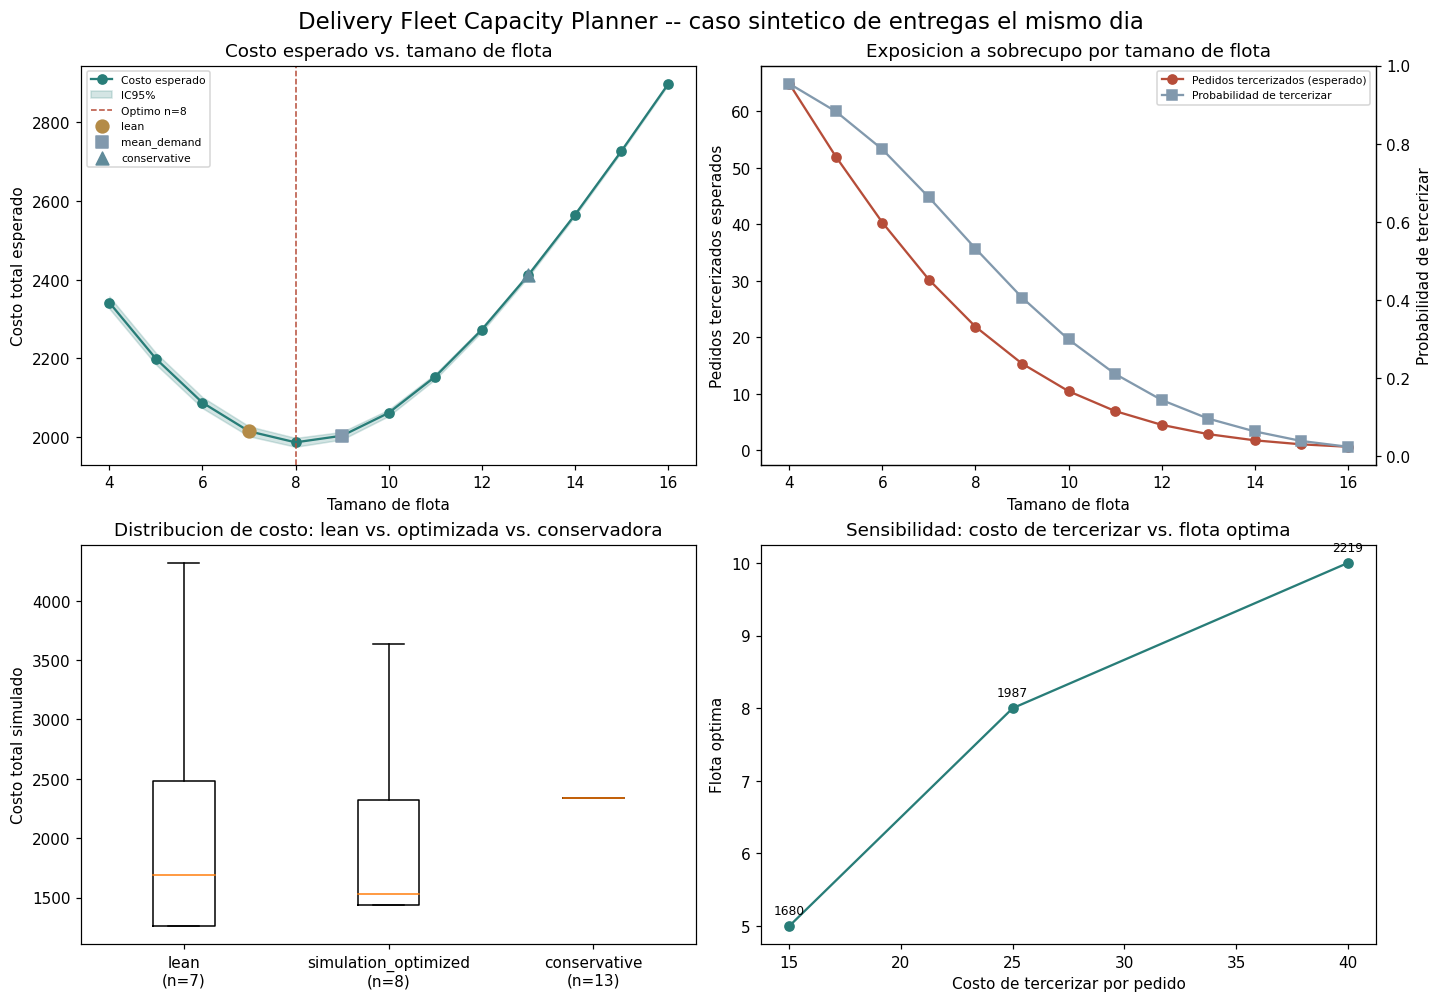

In [30]:
# El planeador completo es el producto de decision: cuantos vehiculos reservar y por que.

planner.suptitle("Delivery Fleet Capacity Planner -- caso sintetico de entregas el mismo dia", fontsize=15)
display(planner)

In [31]:
# Verificamos el caso completo antes de generar los artefactos de entrega.

assert len(fleet_evaluation) == 13
assert optimal_fleet_size == 8
assert second_best_size == 9
assert np.isclose(gap, 16.8789, atol=0.01)
assert np.isclose(demand_variance, 1920.0)
assert np.isclose(demand_sd, 43.818, atol=0.001)
assert (paired_7_8["ci95_low"] > 0) or (paired_7_8["ci95_high"] < 0)
assert (paired_8_9["ci95_low"] > 0) or (paired_8_9["ci95_high"] < 0)
assert outsourcing_cost_sensitivity.optimal_fleet_size.tolist() == [5, 8, 10]
assert len(reference_policies) == 4
print("Verificado: optimo n=8, vecinos separados por comparacion pareada, sensibilidad 5/8/10 "
      "y varianza de demanda 1920 consistentes.")

Verificado: optimo n=8, vecinos separados por comparacion pareada, sensibilidad 5/8/10 y varianza de demanda 1920 consistentes.


In [32]:
# Guardamos la evaluacion de flota, las politicas de referencia, la sensibilidad y el planeador; no se vuelve a mostrar.

submission_dir.mkdir(exist_ok=True)
fleet_evaluation.to_csv(submission_dir / "fleet_evaluation.csv", index=False)
reference_policies.to_csv(submission_dir / "reference_policies.csv", index=False)
outsourcing_cost_sensitivity.to_csv(submission_dir / "outsourcing_cost_sensitivity.csv", index=False)
planner.savefig(submission_dir / "delivery_fleet_capacity_planner.png", dpi=180, bbox_inches="tight", facecolor="white")
display(
    [
        str(submission_dir / name)
        for name in [
            "fleet_evaluation.csv",
            "reference_policies.csv",
            "outsourcing_cost_sensitivity.csv",
            "delivery_fleet_capacity_planner.png",
        ]
    ]
)

['../submission/fleet_evaluation.csv',
 '../submission/reference_policies.csv',
 '../submission/outsourcing_cost_sensitivity.csv',
 '../submission/delivery_fleet_capacity_planner.png']